In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from pprint import pprint
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tabulate import tabulate
import asyncio
import nest_asyncio
nest_asyncio.apply()
config = {
    "dataset":{
        "dti":"../../Data/scope_onside_common_v3.parquet",
        "adr":"../../Data/final_rxnorm_meddra_v2.parquet"
    },
    "protein_emb_1":{
        "path":  "../../Data/3. Protein_enbeddings/ESM_embeddings_(t33_650m model).parquet",
        "id_col": "id", 
        "emb_col": "embedding"
    },
    "protein_emb_2":{
        "path": "../../Data/3. Protein_enbeddings/GVP-GNN_protein_embeddings.parquet",
        "id_col": "uniprot_id", 
        "emb_col": "embedding"
    },
    "drug_emb_1":{
        "path": "../../Data/2. Drug_embeddings/EGNN_drug_embeddings_v2.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    },
    "drug_emb_2":{
        "path": "../../Data/2. Drug_embeddings/smiles_embeddings_chemberta.parquet", 
        "id_col": "drug_chembl_id", 
        "emb_col": "embedding"
    }
}

In [2]:
dti_df = pd.read_parquet(config["dataset"]["dti"])
print(dti_df.info())

# copy selected columns to a new df
# drug_chembl_id as drug_id and target_uniprot_id as protein_id
dti_df = dti_df.rename(columns={"drug_chembl_id": "drug_id", "target_uniprot_id": "protein_id"})

df = dti_df.copy()
df = df[["drug_id", "protein_id", "label", "rxcui"]]


if config["protein_emb_1"]["path"]:
    protein_emb_1_df = pd.read_parquet(config["protein_emb_1"]["path"])
    protein_emb_1_df = protein_emb_1_df.rename(columns={config["protein_emb_1"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_1_df[["protein_id", config["protein_emb_1"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_1"]["emb_col"]: "prot_emb_1"})

if config["protein_emb_2"]["path"]:
    protein_emb_2_df = pd.read_parquet(config["protein_emb_2"]["path"])
    protein_emb_2_df = protein_emb_2_df.rename(columns={config["protein_emb_2"]["id_col"]: "protein_id"})
    df = df.merge(protein_emb_2_df[["protein_id", config["protein_emb_2"]["emb_col"]]], on="protein_id", how="left")
    df = df.rename(columns={config["protein_emb_2"]["emb_col"]: "prot_emb_2"})

if config["drug_emb_1"]["path"]:
    drug_emb_1_df = pd.read_parquet(config["drug_emb_1"]["path"])
    drug_emb_1_df = drug_emb_1_df.rename(columns={config["drug_emb_1"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_1_df[["drug_id", config["drug_emb_1"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_1"]["emb_col"]: "drug_emb_1"})

if config["drug_emb_2"]["path"]:
    drug_emb_2_df = pd.read_parquet(config["drug_emb_2"]["path"])
    drug_emb_2_df = drug_emb_2_df.rename(columns={config["drug_emb_2"]["id_col"]: "drug_id"})
    df = df.merge(drug_emb_2_df[["drug_id", config["drug_emb_2"]["emb_col"]]], on="drug_id", how="left")
    df = df.rename(columns={config["drug_emb_2"]["emb_col"]: "drug_emb_2"})



print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   drug_chembl_id     34741 non-null  object
 1   target_uniprot_id  34741 non-null  object
 2   label              34741 non-null  int64 
 3   smiles             34741 non-null  object
 4   sequence           34741 non-null  object
 5   molfile_3d         34741 non-null  object
 6   rxcui              34741 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.9+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34741 entries, 0 to 34740
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   drug_id     34741 non-null  object
 1   protein_id  34741 non-null  object
 2   label       34741 non-null  int64 
 3   rxcui       34741 non-null  object
 4   prot_emb_1  34741 non-null  object
 5   prot_emb_2  34741 non

In [3]:

class ADRData:
    def __init__(self, id_to_name_dict):
        """
        Initializes with a dictionary of {meddra_id: meddra_name}.
        """
        self.id_to_name = id_to_name_dict
        self.unique_ids = sorted(list(id_to_name_dict.keys()))
        
        self.id_to_idx = {adr_id: i for i, adr_id in enumerate(self.unique_ids)}
        self.idx_to_id = {i: adr_id for i, adr_id in enumerate(self.unique_ids)}
        
        self.vocab_size = len(self.unique_ids)

    def encode(self, adr_list):
        """
        Takes a list of ADR IDs and returns a binary vector (1s and 0s).
        Example: ['10028553', '10003041'] -> [0, 1, 0, 0, 1...]
        """
        vector = np.zeros(self.vocab_size, dtype=np.int8)
        
        for adr_id in adr_list:
            if adr_id in self.id_to_idx:
                idx = self.id_to_idx[adr_id]
                vector[idx] = 1
            else:
                print(f"Warning: ADR ID {adr_id} not in vocabulary.")
                
        return vector

    def decode(self, vector):
        """
        Takes a binary vector and returns a list of human-readable ADR names.
        """
        decoded_names = []
        
        active_indices = np.where(vector == 1)[0]
        
        for idx in active_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            decoded_names.append(name)
            
        return decoded_names

    def decode_indices(self, indices):
        """
        Takes a list or array of indices (e.g., [42, 105, 300]) 
        and returns the corresponding ADR names.
        """
        return [self.id_to_name.get(self.idx_to_id[idx], "Unknown ADR") for idx in indices]

    def decode_top_k(self, confidence_array, k=5):
        """
        Takes the raw probability array from the model, finds the top K 
        highest values, and returns names + their confidence scores.
        """
        # Get indices of the top k probabilities
        top_indices = np.argsort(confidence_array)[-k:][::-1]
        
        results = []
        for idx in top_indices:
            adr_id = self.idx_to_id[idx]
            name = self.id_to_name.get(adr_id, "Unknown ADR")
            conf = confidence_array[idx]
            results.append({"name": name, "confidence": round(float(conf), 4)})
            
        return results

    def decode_with_threshold(self, confidence_array, threshold=0.5):
        """
        Returns all ADRs that pass a specific confidence threshold.
        Useful for seeing everything the model is "sure" about.
        """
        active_indices = np.where(confidence_array >= threshold)[0]
        
        # Sort them by confidence (highest first)
        active_indices = active_indices[np.argsort(confidence_array[active_indices])[::-1]]
        
        return [self.id_to_name.get(self.idx_to_id[idx], "Unknown ADR") for idx in active_indices]


In [4]:
adrdf = pd.read_parquet(config['dataset']["adr"])
id_name_dict = dict(zip(adrdf['meddra_id'], adrdf['meddra_name']))
adr_manager = ADRData(id_name_dict)

In [5]:
drug_to_adr_list = adrdf.groupby('rxnorm_ingredient_id')['meddra_id'].apply(list).to_dict()

def get_encoded_adr(drug_id):
    # Get the list of ADRs for this drug, or an empty list if not found
    adrs = drug_to_adr_list.get(drug_id, [])
    return adr_manager.encode(adrs)

# 2. Map the drug_id (e.g., rxcui) to the encoded vector
# This will create a column where each cell is a numpy array
df['adr'] = df['rxcui'].map(get_encoded_adr)
print(f"Total rows with ADRs: {df['adr'].apply(lambda x: x.sum() > 0).sum()}")

Total rows with ADRs: 34741


In [6]:
# print number of unique protein and drug ids

print(df["protein_id"].nunique())
print(df["drug_id"].nunique())

# print number of unique rxcui
print(df["rxcui"].nunique())
print(df.head(5))


2385
1028
1028
      drug_id protein_id  label  rxcui  \
0  CHEMBL1000     O15245      0  20610   
1  CHEMBL1000     P08183      1  20610   
2  CHEMBL1000     P35367      1  20610   
3  CHEMBL1000     Q02763      0  20610   
4  CHEMBL1000     Q12809      0  20610   

                                          prot_emb_1  \
0  [-0.041778564453125, 0.0305938720703125, -0.01...   
1  [-0.01091766357421875, -0.0694580078125, -0.07...   
2  [-0.00229644775390625, -0.083740234375, -0.053...   
3  [0.01076507568359375, -0.042083740234375, -0.0...   
4  [0.0037441253662109375, -0.042205810546875, -0...   

                                          prot_emb_2  \
0  [0.143310546875, 0.340087890625, -0.3349609375...   
1  [0.1385498046875, 0.329833984375, -0.325439453...   
2  [0.1802978515625, 0.34619140625, -0.3278808593...   
3  [0.1541748046875, 0.33154296875, -0.326171875,...   
4  [0.1766357421875, 0.342041015625, -0.335693359...   

                                          drug_emb_1  \
0 

In [7]:
from sklearn.model_selection import train_test_split

# 1. Get all unique protein IDs
unique_proteins = df['protein_id'].unique()

# 2. Split protein IDs (not rows) to ensure no leakage
# We'll reserve 10% of proteins for Test and 10% for Validation
train_prot_ids, temp_prot_ids = train_test_split(
    unique_proteins, 
    test_size=0.20, 
    random_state=42
)

val_prot_ids, test_prot_ids = train_test_split(
    temp_prot_ids, 
    test_size=0.50, 
    random_state=42
)

# 3. Create the dataframes based on these ID splits
train_df = df[df['protein_id'].isin(train_prot_ids)]
val_df = df[df['protein_id'].isin(val_prot_ids)]
test_df = df[df['protein_id'].isin(test_prot_ids)]

# --- Verification & Metrics ---
print(f"--- Final Dataset Sizes ---")
print(f"Train Set: {len(train_df)} rows ({len(train_prot_ids)} proteins)")
print(f"Val Set:   {len(val_df)} rows ({len(val_prot_ids)} proteins) - [Model Selection]")
print(f"Test Set:  {len(test_df)} rows ({len(test_prot_ids)} proteins) - [Cold-Protein Eval]")

# 4. Recalculate Positive Weight for Training
num_neg = (train_df['label'] == 0).sum()
num_pos = (train_df['label'] == 1).sum()

# Avoid division by zero just in case
pos_weight_value = num_neg / num_pos if num_pos > 0 else 1.0

print(f"\nNew Positive Weight: {pos_weight_value:.2f}")
print(f"Positive/Negative Ratio in Train: 1:{num_neg/num_pos:.2f}")

--- Final Dataset Sizes ---
Train Set: 28055 rows (1908 proteins)
Val Set:   3335 rows (238 proteins) - [Model Selection]
Test Set:  3351 rows (239 proteins) - [Cold-Protein Eval]

New Positive Weight: 1.75
Positive/Negative Ratio in Train: 1:1.75


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FusionModule(nn.Module):
    def __init__(self, dim1, dim2, output_dim):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(dim1 + dim2, output_dim),
            # eps=1e-5 adds stability to the division
            nn.LayerNorm(output_dim), 
            nn.ReLU(),
            nn.Dropout(0.1)
        )
    def forward(self, e1, e2):
        return self.fusion(torch.cat([e1, e2], dim=1))

class MultiTaskFusionVAE(nn.Module):
    def __init__(self, drug_dims, prot_dims, adr_dim=4817, fused_dim=1024, latent_dim=768):
        super().__init__()
        
        # 1. Fusion Layers
        self.drug_fusion = FusionModule(drug_dims[0], drug_dims[1], fused_dim)
        self.prot_fusion = FusionModule(prot_dims[0], prot_dims[1], fused_dim)
        
        # 2. Contextual Encoder 
        self.context_encoder = nn.Sequential(
            nn.Linear(prot_dims[0] + drug_dims[0], 1536), # Expand slightly first
            nn.ReLU(),
            nn.Dropout(0.2),                # Adding dropout because 768-D is prone to overfitting
            nn.Linear(1536, 1024),
            nn.ReLU(),
            nn.Linear(1024, 768)            # Feeds into fc_mu and fc_logvar
        )
        
        # 3. VAE Bottleneck
        self.fc_mu = nn.Linear(768, latent_dim)
        self.fc_logvar = nn.Linear(768, latent_dim)
        
        # 4. Multi-task Heads
        self.adr_decoder = nn.Sequential(
            nn.Linear(latent_dim, 1536),
            nn.ReLU(),
            nn.Linear(1536, adr_dim)
        )
        
        self.dti_head = nn.Sequential(
            nn.Linear(latent_dim, 384),
            nn.ReLU(),
            nn.Dropout(0.2), # Increased dropout for DTI generalization
            nn.Linear(384, 1)
        )

    def reparameterize(self, mu, logvar):
        # STABILITY FIX: Clamp logvar to prevent exp(logvar) from hitting infinity
        logvar = torch.clamp(logvar, min=-10, max=10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, d1, d2, p1, p2):
        fd = d1
        fp = p1
        
        # Concat: [Drug, Protein, Interaction]
        context_input = torch.cat([fd, fp], dim=1)
        context = self.context_encoder(context_input)
        
        mu = self.fc_mu(context)
        logvar = self.fc_logvar(context)

        z = self.reparameterize(mu, logvar)
        
        adr_logits = self.adr_decoder(z)
        dti_logits = self.dti_head(z)
        
        return dti_logits, adr_logits, mu, logvar

In [27]:
class MultiTaskLossWrapper(nn.Module):
    def __init__(self, num_tasks=2):
        super(MultiTaskLossWrapper, self).__init__()
        # These represent the 'noise' or uncertainty of each task
        self.log_vars = nn.Parameter(torch.zeros(num_tasks))

    def forward(self, loss_dti, loss_adr):
        # Task 1: DTI
        precision1 = torch.exp(-self.log_vars[0])
        loss1 = precision1 * loss_dti + self.log_vars[0]

        # Task 2: ADR
        precision2 = torch.exp(-self.log_vars[1])
        loss2 = precision2 * loss_adr + self.log_vars[1]

        return loss1 + loss2


In [28]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, 
    precision_recall_curve, auc, precision_score, recall_score, average_precision_score
)

def evaluate_multitask(model, dataloader, device):
    model.eval()
    
    # Storage for DTI targets and predictions
    dti_true, dti_probs = [], []
    # Storage for ADR targets and predictions
    adr_true, adr_probs = [], []

    with torch.no_grad():
        for d1, d2, p1, p2, labels, adr_targets in dataloader:
            d1, d2, p1, p2 = d1.to(device), d2.to(device), p1.to(device), p2.to(device)
            
            # Forward pass
            dti_logits, adr_logits, _, _ = model(d1, d2, p1, p2)
            
            # Convert to probabilities
            dti_p = torch.sigmoid(dti_logits).cpu().numpy()
            adr_p = torch.sigmoid(adr_logits).cpu().numpy()
            
            dti_true.extend(labels.numpy())
            dti_probs.extend(dti_p)
            
            adr_true.extend(adr_targets.numpy())
            adr_probs.extend(adr_p)

    # --- 1. DTI METRICS ---
    dti_true = np.array(dti_true)
    dti_probs = np.array(dti_probs).flatten()
    dti_preds = (dti_probs > 0.5).astype(int)

    # Calculate Precision-Recall AUC (AUPRC)
    precision_pts, recall_pts, _ = precision_recall_curve(dti_true, dti_probs)
    auprc = auc(recall_pts, precision_pts)

    dti_results = {
        "DTI_Accuracy": accuracy_score(dti_true, dti_preds),
        "DTI_F1": f1_score(dti_true, dti_preds),
        "DTI_Precision": precision_score(dti_true, dti_preds),
        "DTI_Recall": recall_score(dti_true, dti_preds),
        "DTI_AUROC": roc_auc_score(dti_true, dti_probs),
        "DTI_AUPRC": auprc
    }

    # --- 2. ADR METRICS (Micro-averaged across 4,817 labels) ---
    adr_true = np.array(adr_true)
    adr_probs = np.array(adr_probs)
    adr_preds = (adr_probs > 0.5).astype(int)
    
    # For ADRs, we usually report Micro-average because labels are sparse
    adr_results = {
        "ADR_Micro_AUROC": roc_auc_score(adr_true, adr_probs, average='micro'),
        "ADR_Macro_AUROC": roc_auc_score(adr_true, adr_probs, average='macro'),
        "ADR_Weighted_AUROC": roc_auc_score(adr_true, adr_probs, average='weighted'),
        "ADR_Weighted_AUPRC": average_precision_score(adr_true, adr_probs, average='weighted'), # Approx
        "ADR_Micro_AUPRC": average_precision_score(adr_true, adr_probs, average='micro'), # Approx
        "ADR_Macro_AUPRC": average_precision_score(adr_true, adr_probs, average='macro'), # Approx
        "ADR_F1": f1_score(adr_true, adr_preds, average="weighted")
    }

    return {**dti_results, **adr_results}

In [29]:

class DTIVAE_Dataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Drug Inputs (Fusion)
        d1 = torch.tensor(row['drug_emb_1'], dtype=torch.float)
        d2 = torch.tensor(row['drug_emb_2'], dtype=torch.float)
        
        # Protein Inputs (Fusion)
        p1 = torch.tensor(row['prot_emb_1'], dtype=torch.float)
        p2 = torch.tensor(row['prot_emb_2'], dtype=torch.float)
        
        # Targets
        label = torch.tensor(row['label'], dtype=torch.float)
        adr_vector = torch.tensor(row['adr'], dtype=torch.float)
        
        return d1, d2, p1, p2, label, adr_vector



In [30]:
train_loader = DataLoader(DTIVAE_Dataset(train_df), batch_size=64, shuffle=True)
val_loader = DataLoader(DTIVAE_Dataset(val_df), batch_size=64, shuffle=False)
test_loader = DataLoader(DTIVAE_Dataset(test_df), batch_size=64, shuffle=False)

In [31]:


def train_model(model, train_loader, test_loader, val_loader, pos_weight, epochs=50, lr=1e-3, device='cuda', monitor=None, loss_balancer= None):
    model.to(device)

    
    optimizer = torch.optim.Adam([
        {'params': model.parameters()},
        {'params': loss_balancer.parameters()}
    ], lr=lr, weight_decay=1e-4)
    
    scheduler = ReduceLROnPlateau(optimizer, 'max', min_lr= 1e-7,patience=5, factor=0.2)
    
    dti_criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(device))
    
    best_val_auprc = 0
    
    print(f"Starting Training on {device}...")
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        beta = min(0.01, epoch * 0.001)
        
        for d1, d2, p1, p2, labels, adr_targets in train_loader:
            d1, d2, p1, p2 = d1.to(device), d2.to(device), p1.to(device), p2.to(device)
            labels, adr_targets = labels.to(device), adr_targets.to(device)
            
            optimizer.zero_grad()
            
            # Forward Pass
            dti_logits, adr_logits, mu, logvar = model(d1, d2, p1, p2)
            
            loss_dti = dti_criterion(dti_logits.squeeze(), labels)
            loss_adr = F.binary_cross_entropy_with_logits(adr_logits, adr_targets)
            
            kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            kl_loss /= (adr_targets.size(0) * adr_targets.size(1))
            
            balanced_task_loss = loss_balancer(loss_dti, loss_adr)
            total_loss = balanced_task_loss + (beta * kl_loss)

            
            total_loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            train_losses.append(total_loss.item())
            
        # Evaluation step after each epoch
        test_metrics = evaluate_multitask(model, test_loader, device)
        val_metrics = evaluate_multitask(model, val_loader, device)

        score = 0.6 * val_metrics['DTI_AUPRC'] + 0.4 * val_metrics['ADR_Weighted_AUPRC']
        is_best = score > best_val_auprc
        # 5. Checkpointing the Best Model
        if score > best_val_auprc:
            best_val_auprc = score
            torch.save(model.state_dict(), 'best_multitask_model.pth')
            print(f"*** New Best Model Saved (AUPRC: {best_val_auprc:.4f}) ***")
            
        # Update learning rate based on performance
        scheduler.step(score)
        
        # Calculate learned weights for the thesis report
        with torch.no_grad():
            w_dti = torch.exp(-loss_balancer.log_vars[0]).item()
            w_adr = torch.exp(-loss_balancer.log_vars[1]).item()
        
        table_data = [
            [
                "Test", 
                test_metrics['DTI_AUROC'], 
                test_metrics['DTI_AUPRC'], 
                test_metrics['DTI_F1'], 
                test_metrics['ADR_Micro_AUROC'],
                test_metrics['ADR_Weighted_AUROC'],
                test_metrics['ADR_Micro_AUPRC'],
                test_metrics['ADR_Weighted_AUPRC'],
                test_metrics['ADR_F1']
            ],
            [
                "Validation", 
                val_metrics['DTI_AUROC'], 
                val_metrics['DTI_AUPRC'], 
                val_metrics['DTI_F1'], 
                val_metrics['ADR_Micro_AUROC'],
                val_metrics['ADR_Weighted_AUROC'],
                val_metrics['ADR_Micro_AUPRC'],
                val_metrics['ADR_Weighted_AUPRC'],
                val_metrics['ADR_F1']
            ]
            
        ]
        headers = ["SET","DTI AUROC", "DTI AUPRC", "DTI F1", "ADR MICRO AUROC","ADR WEIGHTED AUROC", "ADR MICRO AUPRC","ADR WEIGHTED AUPRC", "ADR_F1"]

        monitor.log_epoch(epoch, headers, table_data, best = is_best)
        

        # 3. Print the report
        print(f"\n🚀 Epoch {epoch+1}/{epochs} | Loss: {np.mean(train_losses):.4f}")
        print(tabulate(table_data, headers=headers, tablefmt="fancy_grid", floatfmt=".4f"))
        print(f"Weights: w_dti={w_dti:.4f}, w_adr={w_adr:.4f}\n")

    return model

In [32]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sample_row = train_df.iloc[0]

# Detect Drug Dimensions
d1_dim = len(sample_row['drug_emb_1'])
d2_dim = len(sample_row['drug_emb_2'])

# Detect Protein Dimensions
p1_dim = len(sample_row['prot_emb_1'])
p2_dim = len(sample_row['prot_emb_2'])

# Detect ADR Dimension
num_adrs = adr_manager.vocab_size

print(f"--- Detected Dimensions ---")
print(f"Drug Inputs: {d1_dim}, {d2_dim}")
print(f"Protein Inputs: {p1_dim}, {p2_dim}")
print(f"ADR Output: {num_adrs}")

# --- 2. INITIALIZE MODEL ---
# Dim sizes depend on your specific embeddings (e.g., 768 or 1024)
model = MultiTaskFusionVAE(
    drug_dims=[d1_dim, d2_dim], 
    prot_dims=[p1_dim, p2_dim], 
    adr_dim=num_adrs, 
    fused_dim=1024,
    latent_dim=768
).to(device)

# Initialize this before the training loop


Using device: cuda
--- Detected Dimensions ---
Drug Inputs: 256, 384
Protein Inputs: 1280, 1024
ADR Output: 4817


In [101]:
loss_balancer = MultiTaskLossWrapper(num_tasks=2).to(device)


In [98]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from training_monitor import TrainingMonitor

In [ ]:
monitor = TrainingMonitor(server_url='http://localhost:8080', model_name='structure')

monitor.connect()


trained_model = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    val_loader=val_loader,
    pos_weight=1.75,
    epochs=60,
    lr=1e-4,
    device=device,
    monitor=monitor,
    loss_balancer = loss_balancer
)


[VAE_Main_03] Connected to monitoring server.
Starting Training on cuda...
*** New Best Model Saved (AUPRC: 0.8220) ***

🚀 Epoch 1/60 | Loss: 0.4207
╒════════════╤═════════════╤═════════════╤══════════╤═══════════════════╤══════════════════════╤═══════════════════╤══════════════════════╤══════════╕
│ SET        │   DTI AUROC │   DTI AUPRC │   DTI F1 │   ADR MICRO AUROC │   ADR WEIGHTED AUROC │   ADR MICRO AUPRC │   ADR WEIGHTED AUPRC │   ADR_F1 │
╞════════════╪═════════════╪═════════════╪══════════╪═══════════════════╪══════════════════════╪═══════════════════╪══════════════════════╪══════════╡
│ Test       │      0.9186 │      0.8527 │   0.7779 │            0.9937 │               0.9631 │            0.8882 │               0.8646 │   0.7731 │
├────────────┼─────────────┼─────────────┼──────────┼───────────────────┼──────────────────────┼───────────────────┼──────────────────────┼──────────┤
│ Validation │      0.9043 │      0.7800 │   0.7235 │            0.9949 │               0.9688 │

KeyboardInterrupt: 

In [49]:
monitor.finish()

[VAE_Main] Disconnected from server.
[VAE_Main] Finished.


In [33]:
# load model
model.load_state_dict(torch.load("best_multitask_model.pth"))

<All keys matched successfully>

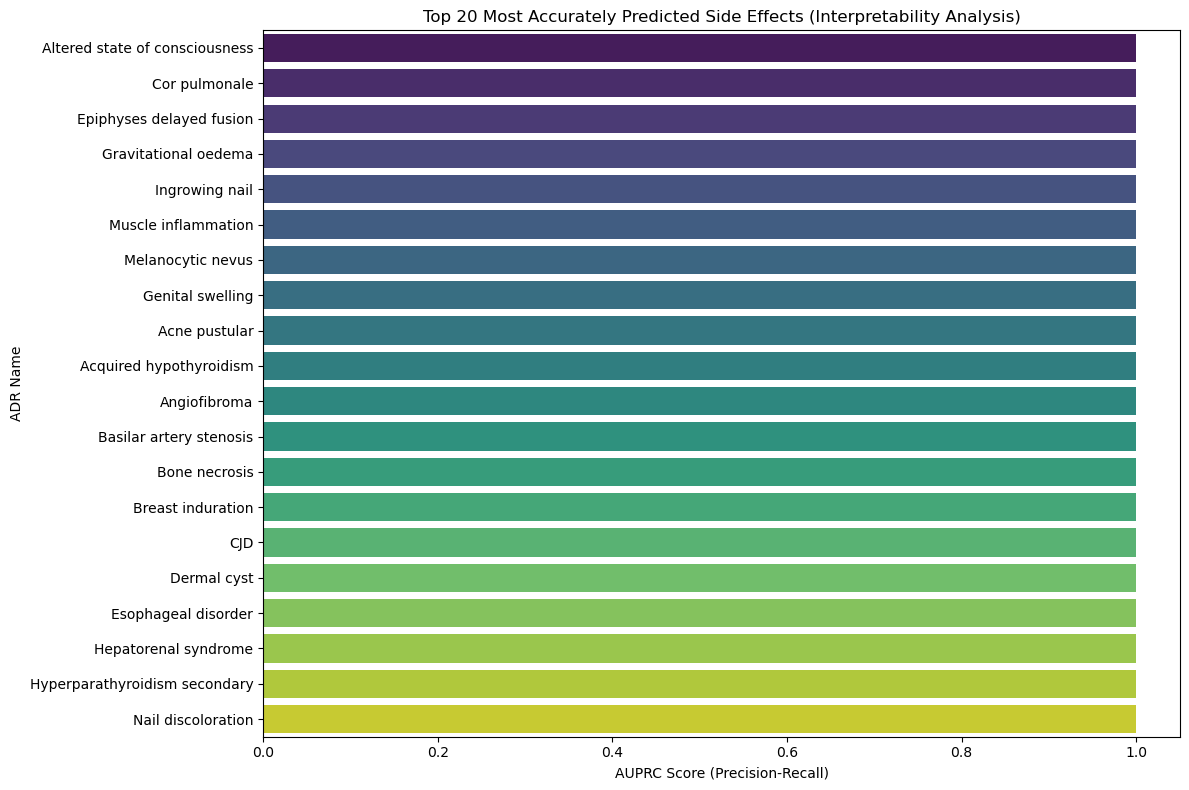

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

def analyze_adr_performance(model, loader, adr_manager, device="cuda", top_n=20):
    model.eval()
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for d1, d2, p1, p2, _, adr_targets in loader:
            _, adr_logits, _, _ = model(d1.to(device), d2.to(device), p1.to(device), p2.to(device))
            all_targets.append(adr_targets.cpu().numpy())
            all_probs.append(torch.sigmoid(adr_logits).cpu().numpy())
            
    all_targets = np.concatenate(all_targets)
    all_probs = np.concatenate(all_probs)
    
    # Calculate AUPRC for each ADR individually
    adr_auprc = []
    for i in range(all_targets.shape[1]):
        if np.sum(all_targets[:, i]) > 0: # Only if ADR exists in set
            score = average_precision_score(all_targets[:, i], all_probs[:, i])
            adr_auprc.append((adr_manager.idx_to_id[i], score))
    
    # Sort and get top N
    adr_auprc.sort(key=lambda x: x[1], reverse=True)
    top_adrs = adr_auprc[:top_n]
    
    # Map IDs to Names for the plot
    plot_data = pd.DataFrame({
        'ADR Name': [adr_manager.id_to_name.get(aid, aid) for aid, score in top_adrs],
        'AUPRC Score': [score for aid, score in top_adrs]
    })
    
    # Create the Heatmap/Barplot
    plt.figure(figsize=(12, 8))
    sns.barplot(x='AUPRC Score', y='ADR Name', data=plot_data, palette='viridis')
    plt.title(f'Top {top_n} Most Accurately Predicted Side Effects (Interpretability Analysis)')
    plt.xlabel('AUPRC Score (Precision-Recall)')
    plt.tight_layout()
    plt.show()

# Run it
analyze_adr_performance(model, test_loader, adr_manager)

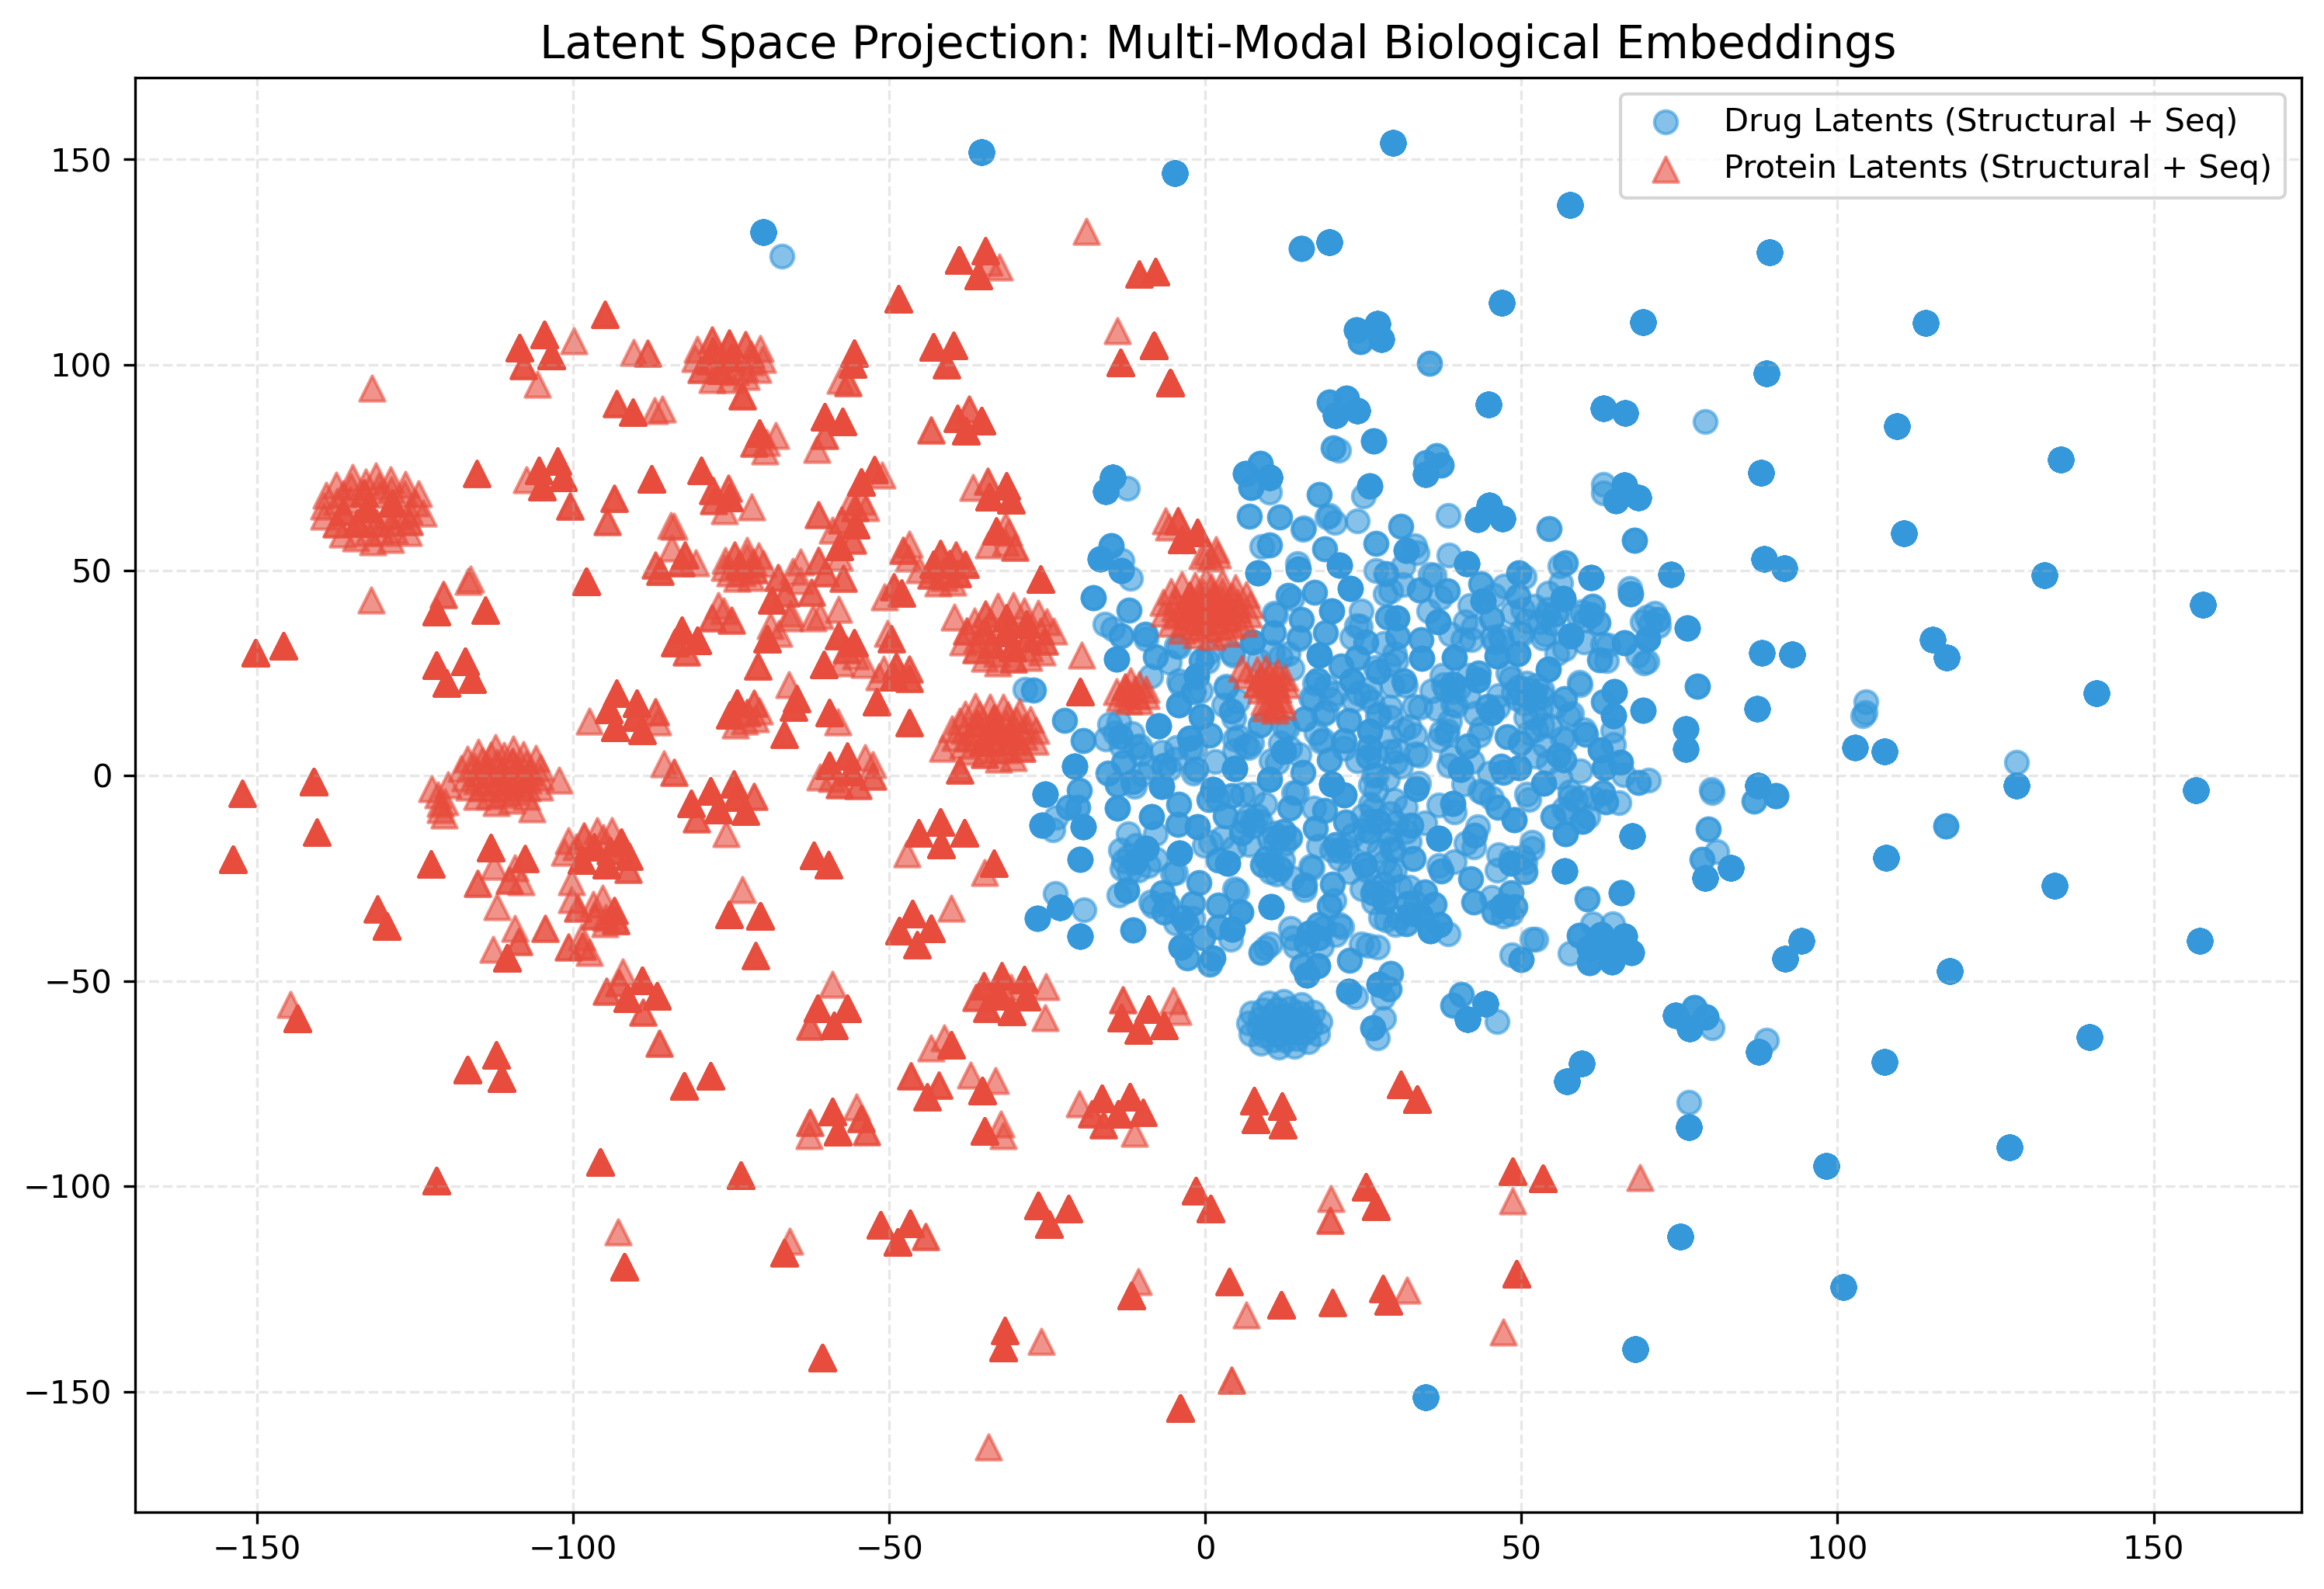

In [48]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_separated_entities(model, loader, device):
    model.eval()
    drug_latents = []
    prot_latents = []
    
    with torch.no_grad():
        for i, batch in enumerate(loader):
            # Unpack the batch (handles different loader structures)
            d1, d2, p1, p2 = [b.to(device) for b in batch[:4]]
            
            # STABILITY FIX: Ensure tensors are at least 2D [Batch, Features]
            # This prevents the "Dimension out of range" error
            if d1.dim() == 1: d1 = d1.unsqueeze(0)
            if d2.dim() == 1: d2 = d2.unsqueeze(0)
            if p1.dim() == 1: p1 = p1.unsqueeze(0)
            if p2.dim() == 1: p2 = p2.unsqueeze(0)
            
            # Extract individual fused features
            f_drug = model.drug_fusion(d1, d2)
            f_prot = model.prot_fusion(p1, p2)
            
            drug_latents.append(f_drug.cpu().numpy())
            prot_latents.append(f_prot.cpu().numpy())
            
            if i > 100: break 
    
    drugs = np.concatenate(drug_latents)
    prots = np.concatenate(prot_latents)
    all_features = np.vstack([drugs, prots])
    
    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
    z_2d = tsne.fit_transform(all_features)
    
    # Split the results back into drug and protein groups
    z_drugs = z_2d[:len(drugs)]
    z_prots = z_2d[len(drugs):]
    
    plt.figure(figsize=(12, 8), dpi=300)
    plt.scatter(z_drugs[:, 0], z_drugs[:, 1], c='#3498db', alpha=0.6, 
                label='Drug Latents (Structural + Seq)', marker='o', s=50)
    plt.scatter(z_prots[:, 0], z_prots[:, 1], c='#e74c3c', alpha=0.6, 
                label='Protein Latents (Structural + Seq)', marker='^', s=60)
    
    plt.title('Latent Space Projection: Multi-Modal Biological Embeddings', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()
# Execute with your trained model
plot_separated_entities(model, test_loader, device)

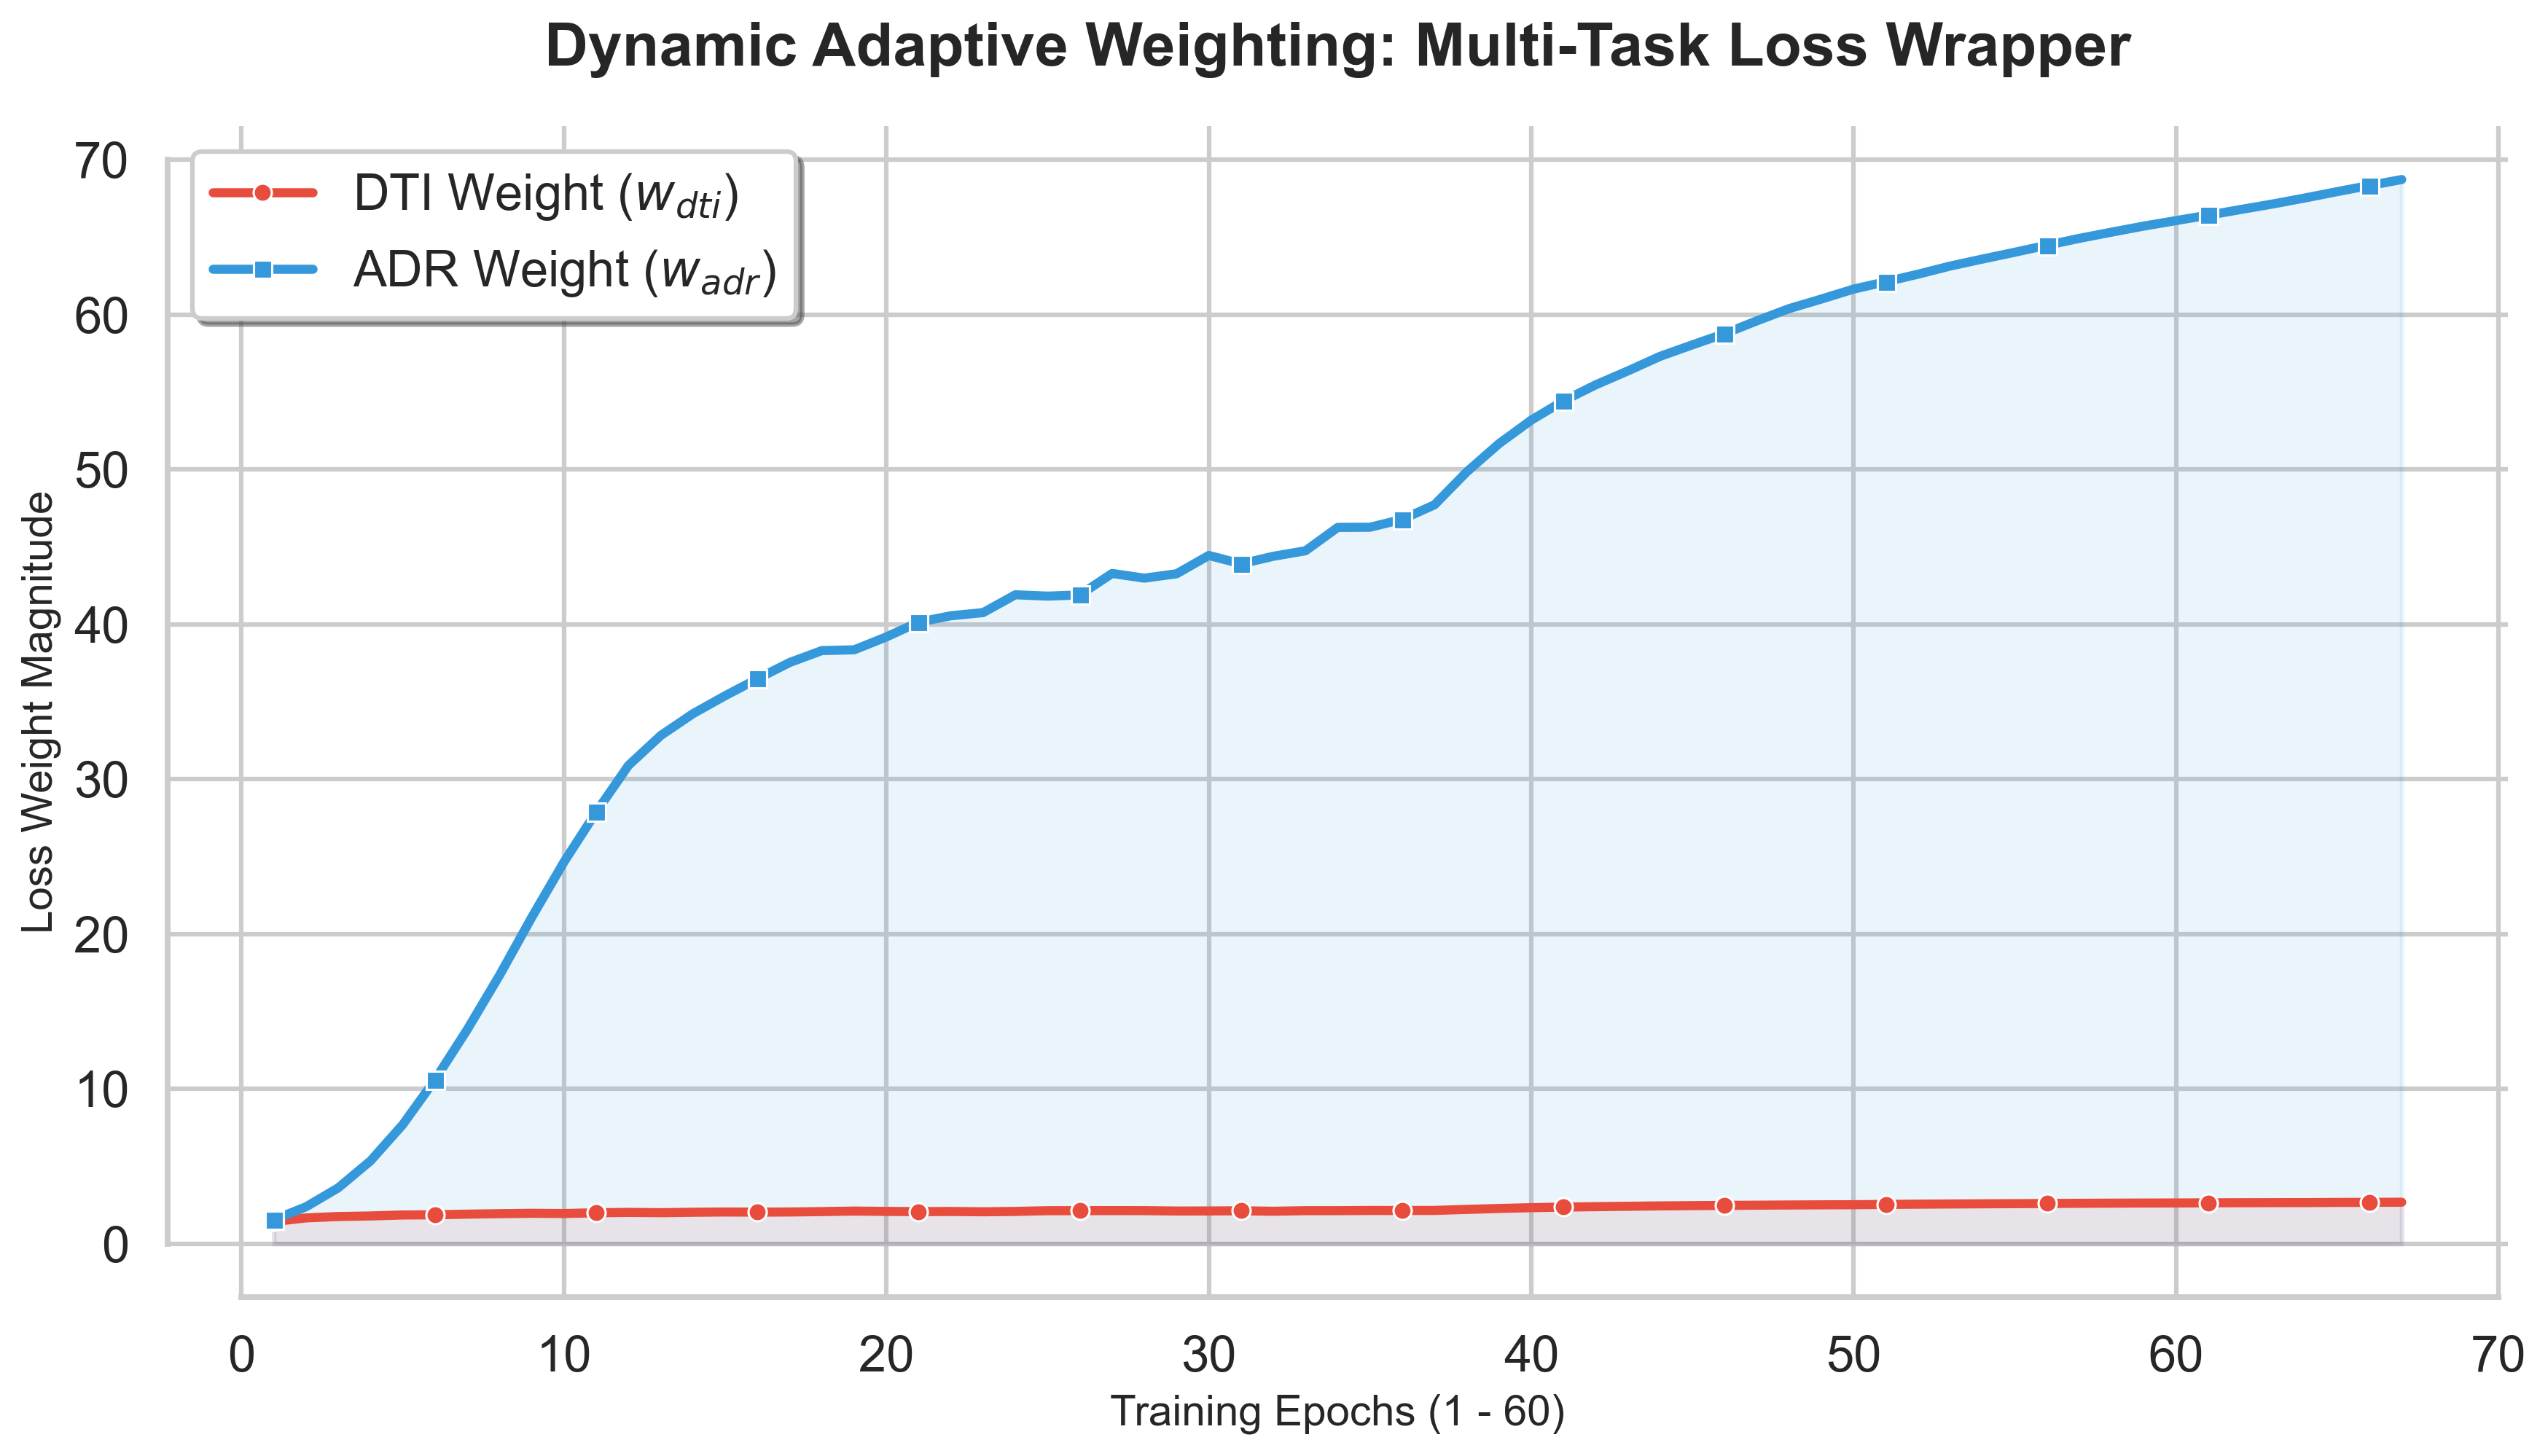

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_loss_weights(csv_path):
    # 1. Set Professional Style
    sns.set_theme(style="whitegrid")
    sns.set_context("talk") # Makes labels and lines thicker for presentations
    
    # 2. Load Data
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found. Please ensure the filename matches.")
        return

    # 3. Create the Figure (High Resolution)
    plt.figure(figsize=(12, 7), dpi=300)
    
    # Define custom professional colors (Deep Coral and Slate Blue)
    colors = ["#E74C3C", "#3498DB"]
    
    # 4. Plot Weight Trajectories
    # We use linewidth=3 and a subtle 'glow' effect by plotting a faint line behind
    sns.lineplot(data=df, x='epoch', y='w_dti', label='DTI Weight ($w_{dti}$)', 
                 color=colors[0], linewidth=3, marker='o', markersize=6, markevery=5)
    
    sns.lineplot(data=df, x='epoch', y='w_adr', label='ADR Weight ($w_{adr}$)', 
                 color=colors[1], linewidth=3, marker='s', markersize=6, markevery=5)

    # 5. Aesthetic Refinements
    plt.fill_between(df['epoch'], df['w_dti'], alpha=0.1, color=colors[0])
    plt.fill_between(df['epoch'], df['w_adr'], alpha=0.1, color=colors[1])

    plt.title('Dynamic Adaptive Weighting: Multi-Task Loss Wrapper', fontsize=20, fontweight='bold', pad=20)
    plt.xlabel('Training Epochs (1 - 60)', fontsize=14)
    plt.ylabel('Loss Weight Magnitude', fontsize=14)
    
    # Optimize the legend
    plt.legend(frameon=True, shadow=True, facecolor='white', loc='upper left')
    
    # Final cleanup
    sns.despine(trim=True)
    plt.tight_layout()
    
    # 6. Export for Paper/Presentation
    plt.savefig('loss_weight_evolution.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('loss_weight_evolution.png', format='png', bbox_inches='tight')
    plt.show()

# Run the function
# plot_loss_weights('training_history.csv')
plot_loss_weights('../EpochValues/training_history01.csv')

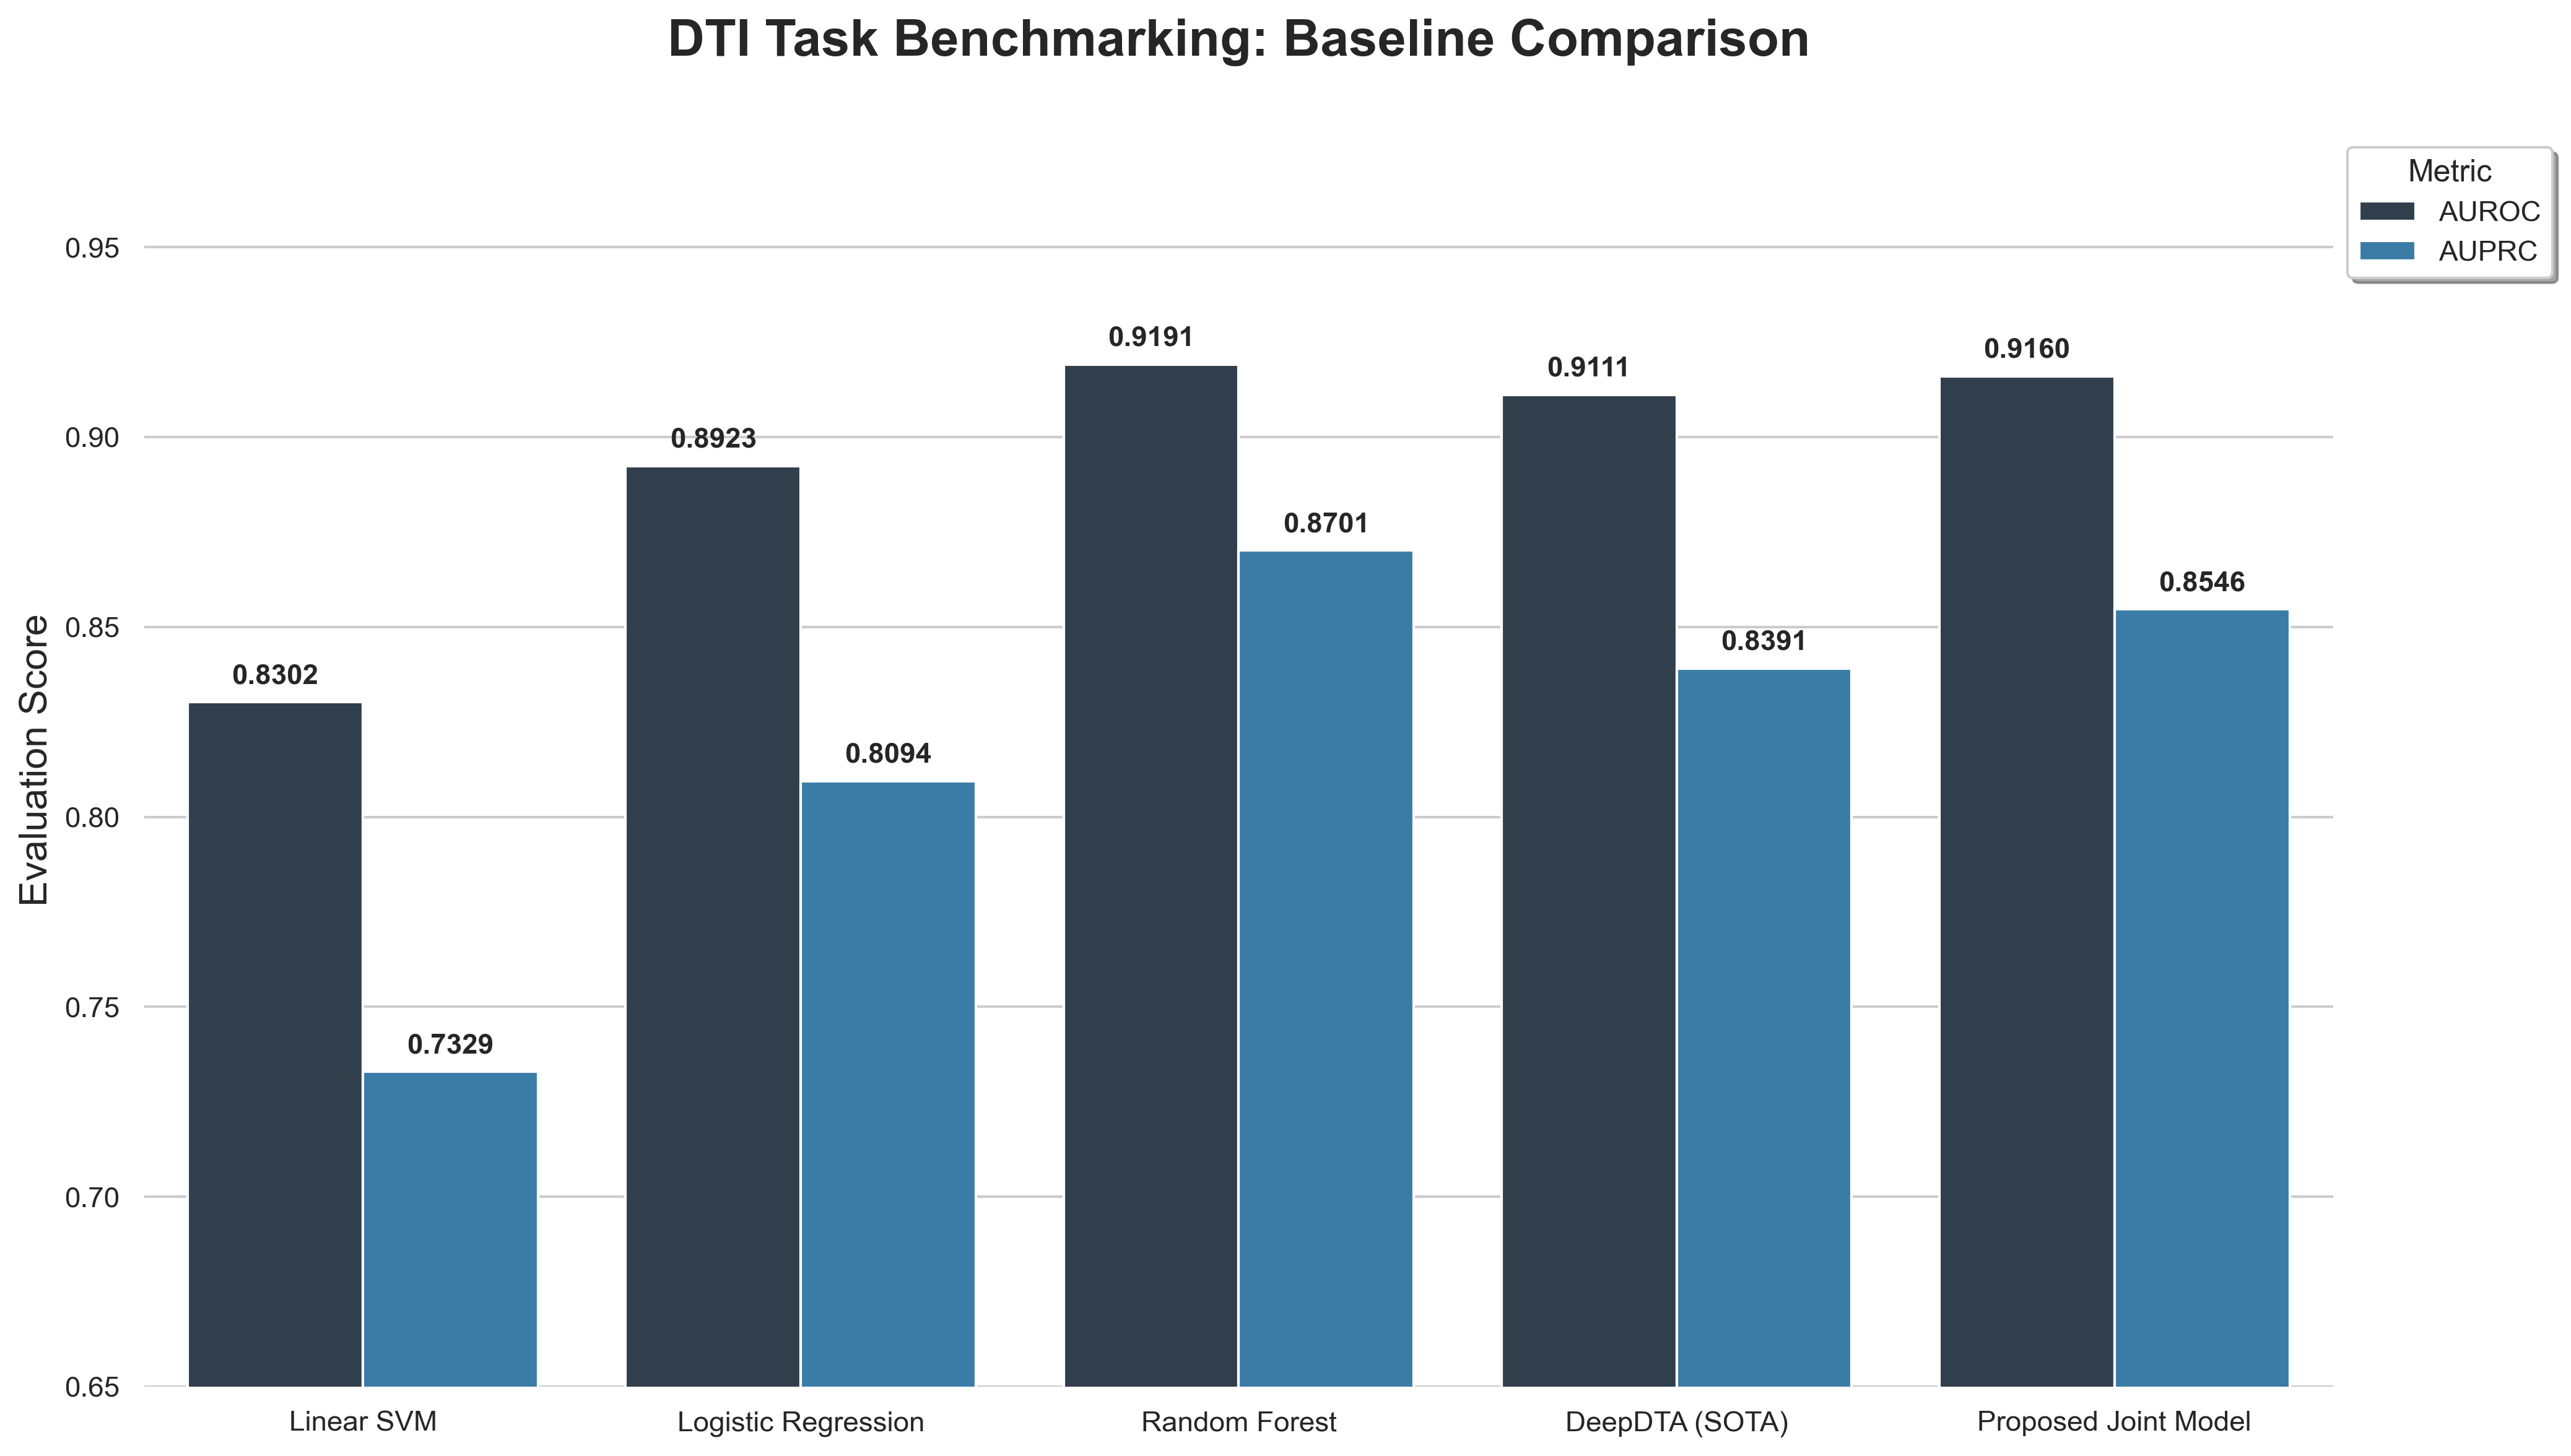

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data provided
data = {
    'Model': ['Linear SVM', 'Logistic Regression', 'Random Forest', 'DeepDTA (SOTA)', 'Proposed Joint Model'],
    'AUROC': [0.8302, 0.8923, 0.9191, 0.9111, 0.9160],
    'AUPRC': [0.7329, 0.8094, 0.8701, 0.8391, 0.8546]
}

df = pd.DataFrame(data)

# 2. Convert to Long-form for Seaborn
df_melted = df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 3. Set Professional Style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8), dpi=300)

# 4. Create Grouped Bar Plot
# Using Slate and Azure colors for a modern scientific look
palette = {"AUROC": "#2C3E50", "AUPRC": "#2980B9"}
ax = sns.barplot(data=df_melted, x='Model', y='Score', hue='Metric', palette=palette)

# 5. Add exact value labels on top of bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), 
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

# 6. Aesthetic Refinements
plt.title('DTI Task Benchmarking: Baseline Comparison', fontsize=20, fontweight='bold', pad=30)
plt.ylabel('Evaluation Score', fontsize=15)
plt.xlabel('', fontsize=15)
plt.ylim(0.65, 0.98)  # Cropping the bottom makes the performance gap easier to see
plt.legend(title='Metric', loc='upper left', bbox_to_anchor=(1, 1), shadow=True)

# Clean up edges
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 7. Exporting
plt.savefig('DTI_Comparison_Results.png', bbox_inches='tight')
plt.savefig('DTI_Comparison_Results.pdf', format='pdf', bbox_inches='tight')
plt.show()

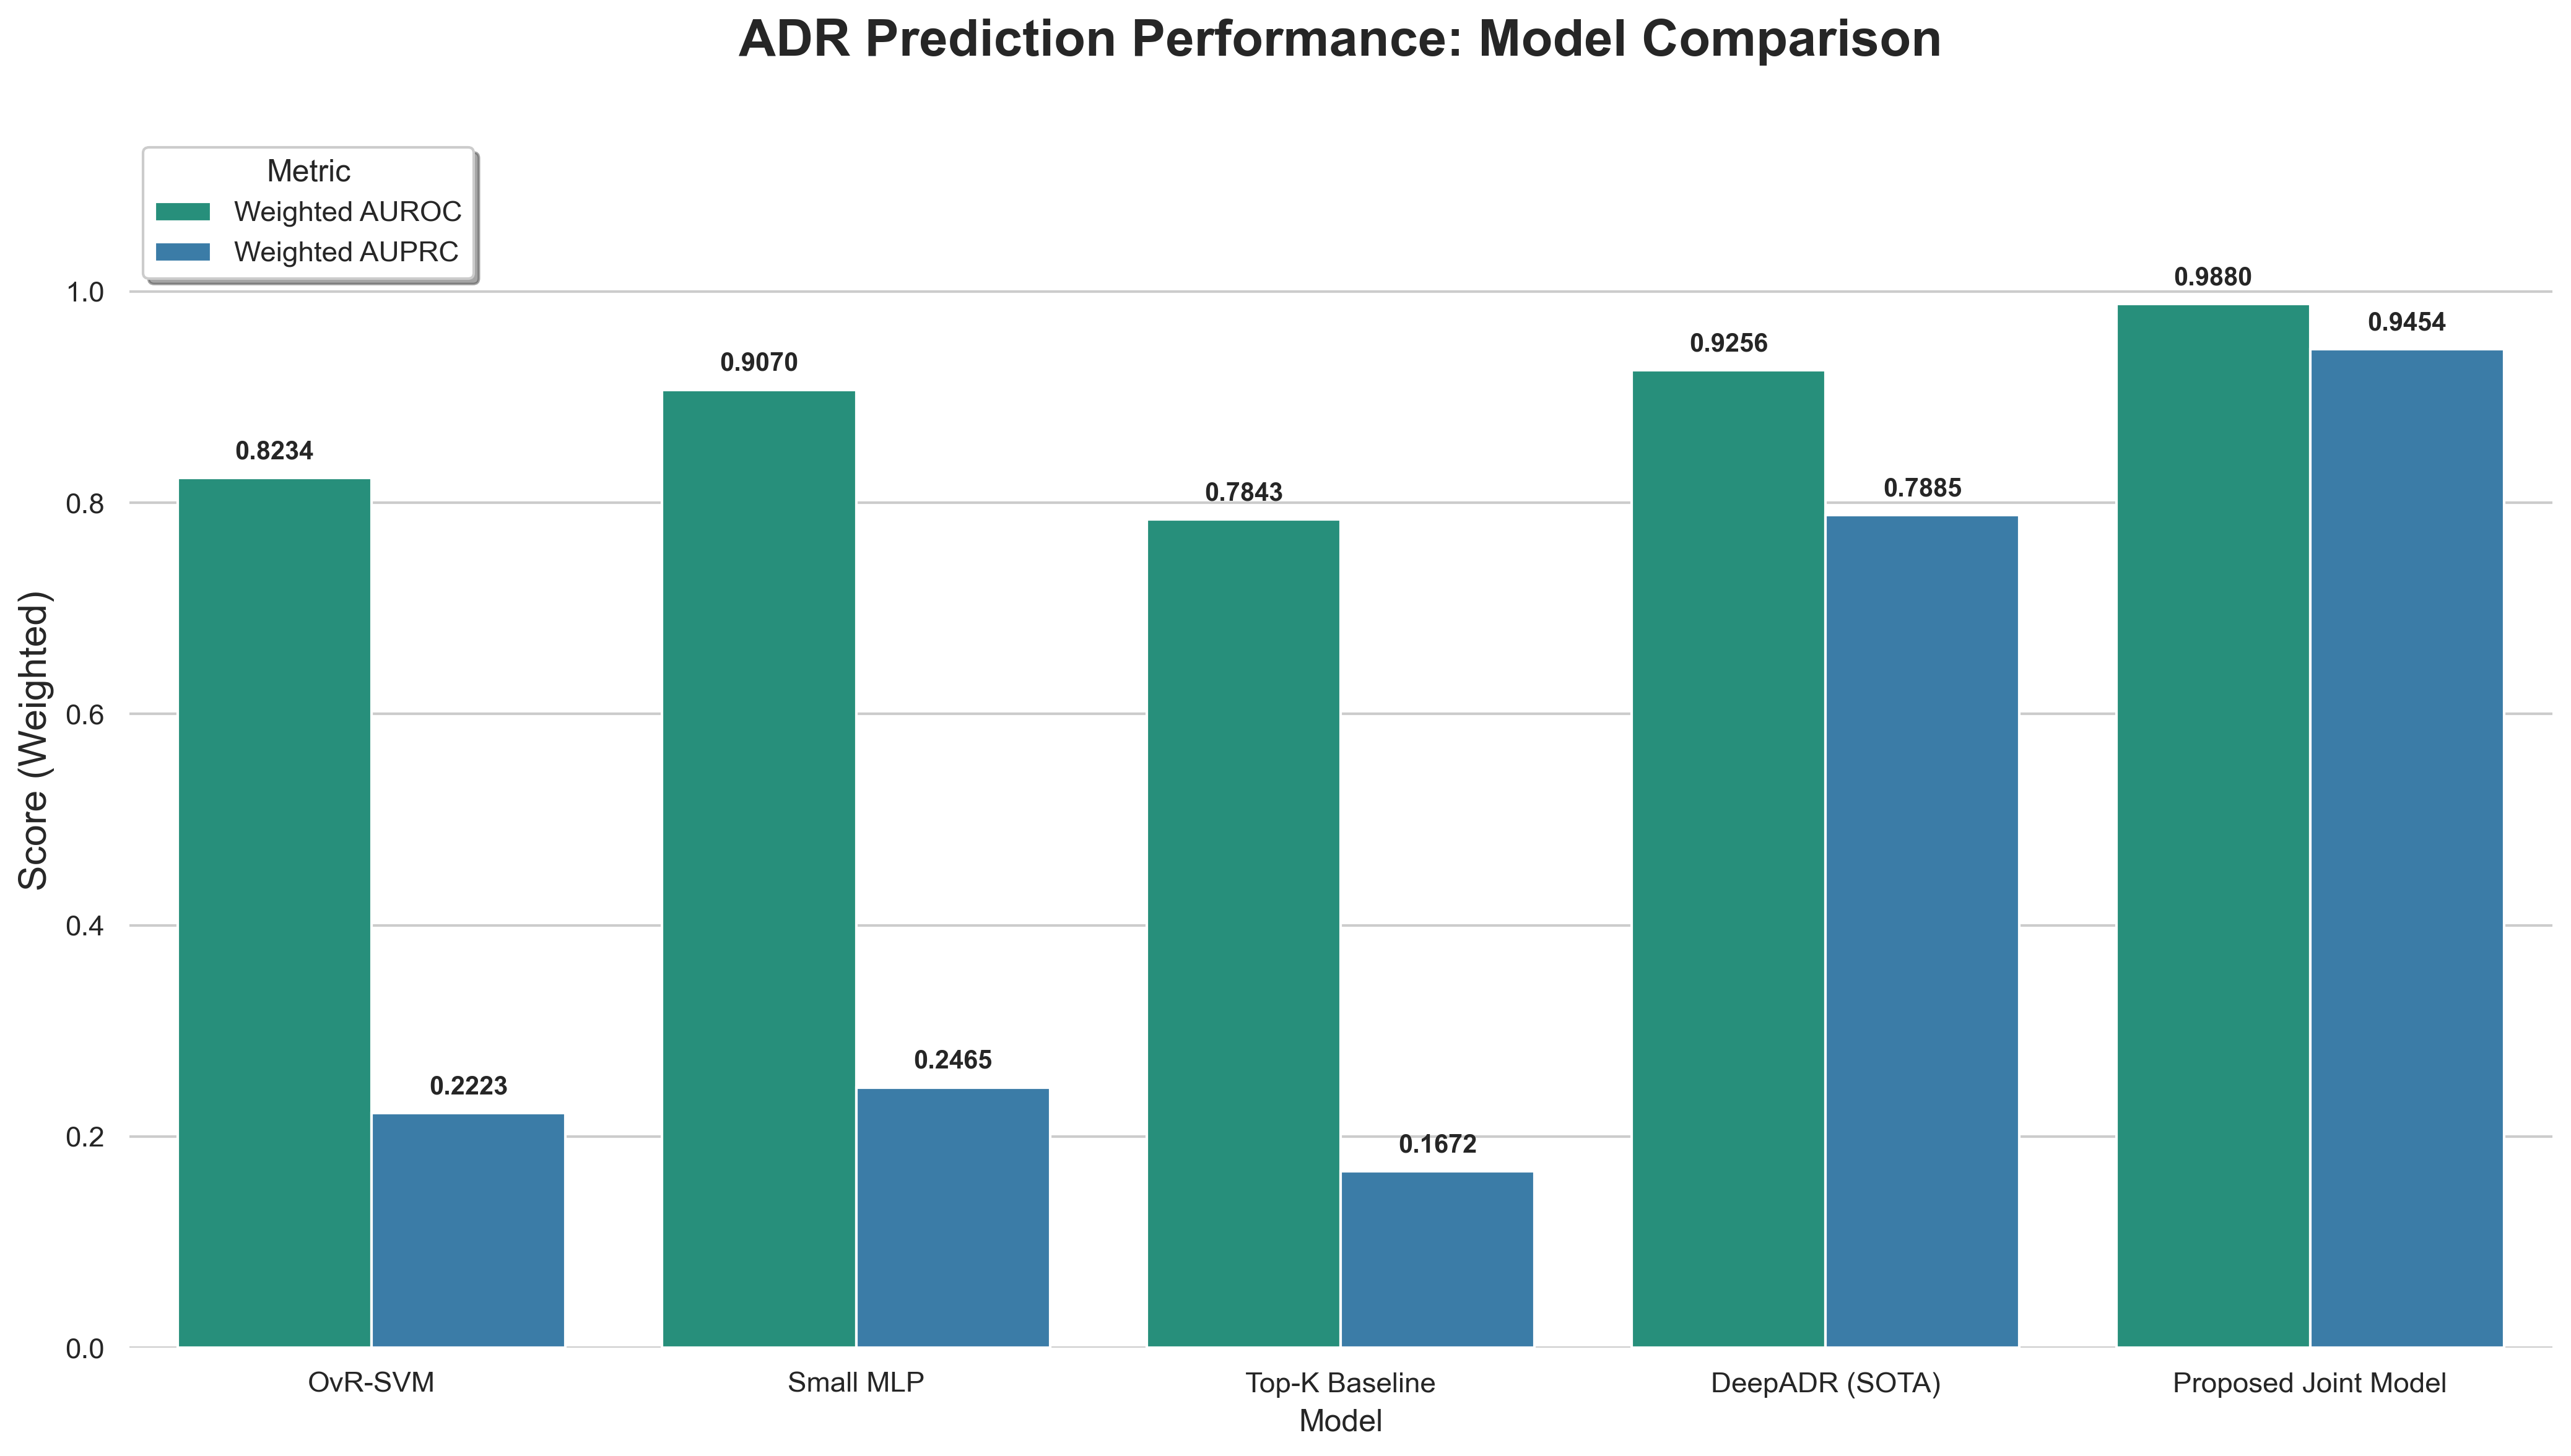

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the data
data_adr = {
    'Model': ['OvR-SVM', 'Small MLP', 'Top-K Baseline', 'DeepADR (SOTA)', 'Proposed Joint Model'],
    'Weighted AUROC': [0.8234, 0.9070, 0.7843, 0.9256, 0.9880],
    'Weighted AUPRC': [0.2223, 0.2465, 0.1672, 0.7885, 0.9454]
}
df_adr = pd.DataFrame(data_adr)
df_adr_melted = df_adr.melt(id_vars='Model', var_name='Metric', value_name='Score')

# 2. Set Professional Style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 8), dpi=300)

# 3. Create Grouped Bar Plot
palette_adr = {"Weighted AUROC": "#16A085", "Weighted AUPRC": "#2980B9"}
ax = sns.barplot(data=df_adr_melted, x='Model', y='Score', hue='Metric', palette=palette_adr)

# 4. Add exact value labels
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(format(height, '.4f'), 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 10), textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

# 5. Aesthetic Refinements
plt.title('ADR Prediction Performance: Model Comparison', fontsize=20, fontweight='bold', pad=30)
plt.ylabel('Score (Weighted)', fontsize=15)
plt.ylim(0, 1.15) 
plt.legend(title='Metric', loc='upper left', shadow=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 6. Save Files
plt.savefig('ADR_Comparison_Results.png', bbox_inches='tight')
plt.savefig('ADR_Comparison_Results.pdf', format='pdf', bbox_inches='tight')

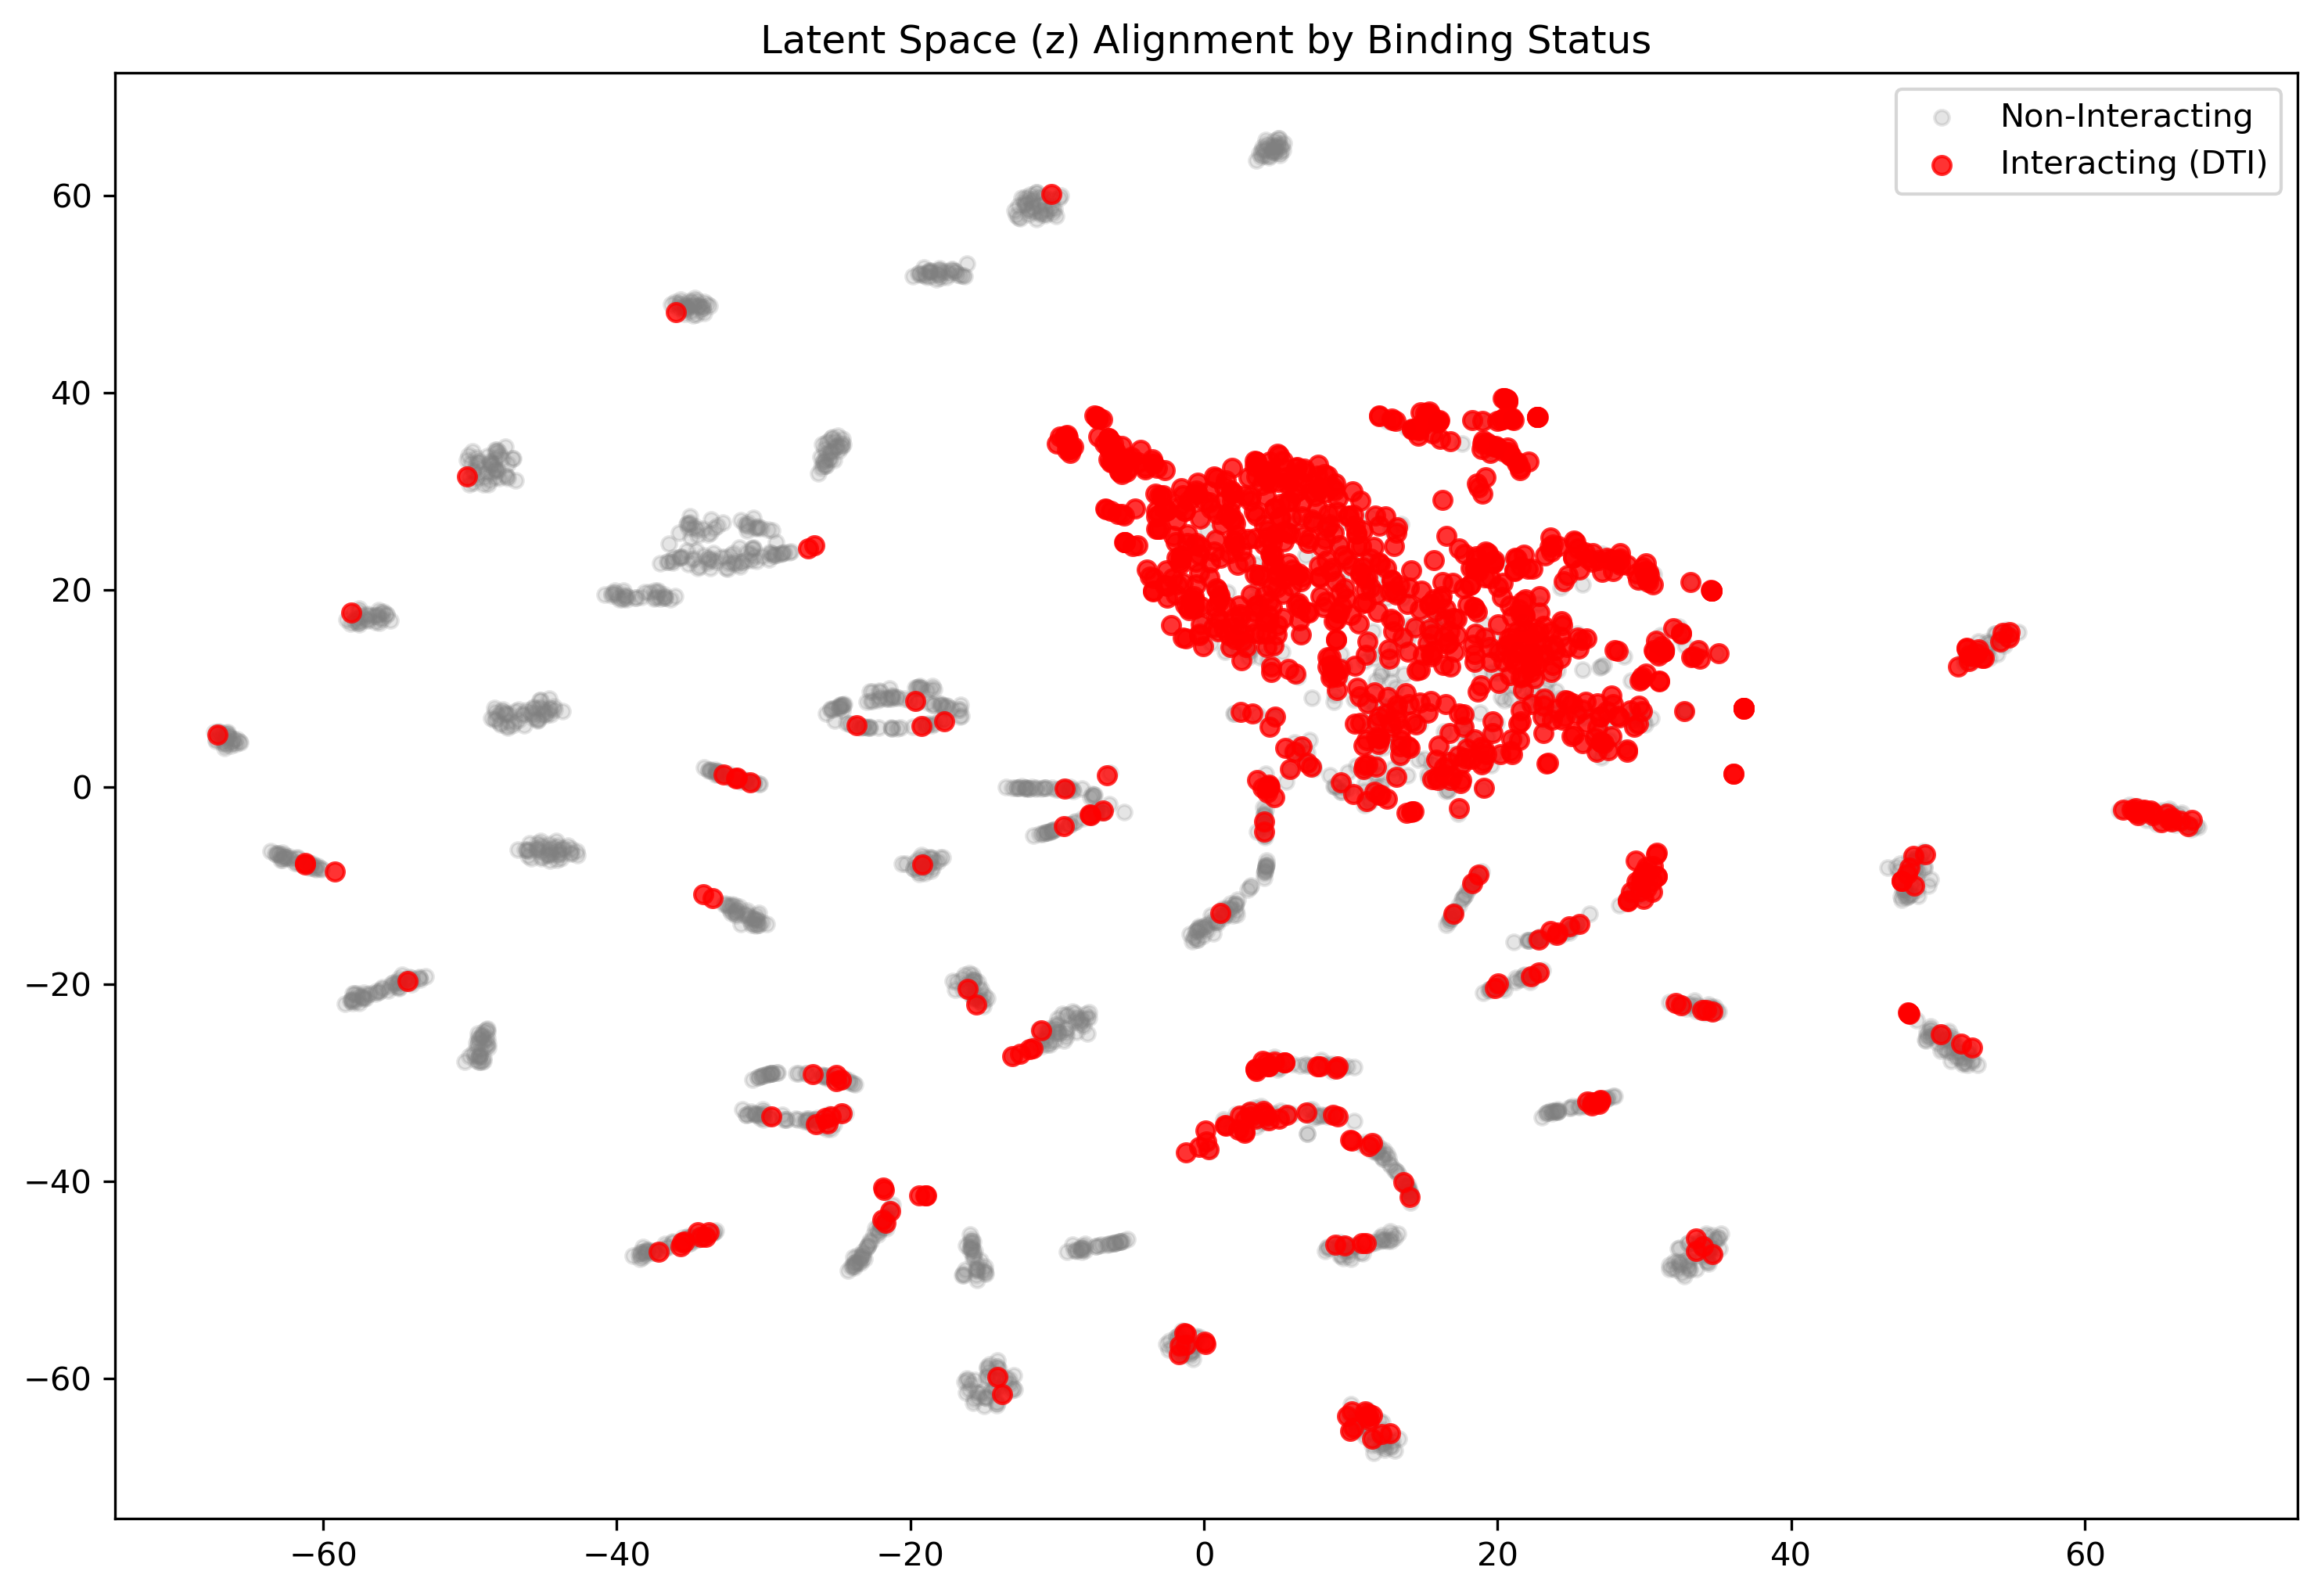

In [43]:
def plot_latent_interaction(model, loader, device):
    model.eval()
    z_list, labels = [], []
    
    with torch.no_grad():
        for batch in loader:
            d1, d2, p1, p2,dti_label, _ = [b.to(device) for b in batch[:10]]
            
            # Forward pass up to z
            fd = model.drug_fusion(d1, d2)
            fp = model.prot_fusion(p1, p2)
            context = model.context_encoder(torch.cat([fd, fp], dim=1))
            mu = model.fc_mu(context) 
            logvar = model.fc_logvar(context)

            z = model.reparameterize(mu, logvar)
            # We use mu as the 'representative' point of the distribution
            
            z_list.append(z.cpu().numpy())
            labels.append(dti_label.cpu().numpy())
            
    z_2d = TSNE(n_components=2).fit_transform(np.concatenate(z_list))
    y = np.concatenate(labels).flatten()

    plt.figure(figsize=(12, 8), dpi=300)

    plt.scatter(z_2d[y==0, 0], z_2d[y==0, 1], c='grey', alpha=0.2, label='Non-Interacting', s=20)
    plt.scatter(z_2d[y==1, 0], z_2d[y==1, 1], c='red', alpha=0.8, label='Interacting (DTI)', s=30)
    plt.title("Latent Space (z) Alignment by Binding Status")
    plt.legend()
    plt.show()

plot_latent_interaction(model, test_loader, device)

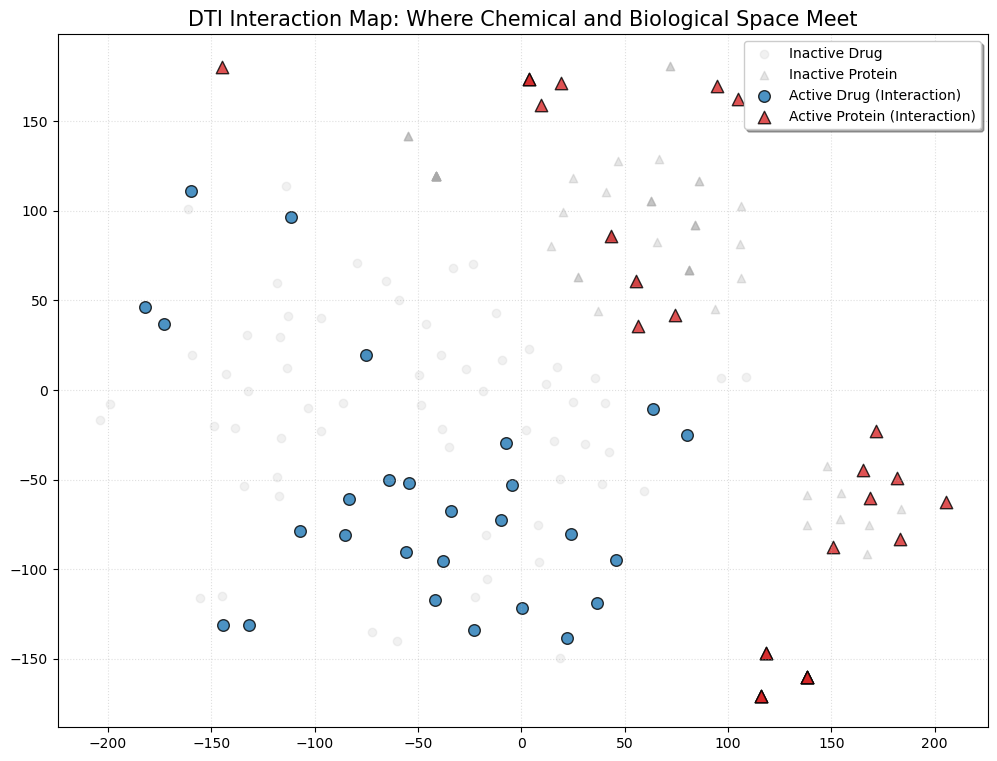

In [167]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_interaction_map(model, loader, device):
    model.eval()
    drug_latents = []
    prot_latents = []
    interaction_labels = []
    
    with torch.no_grad():
        for i, (d1, d2, p1, p2, labels, _) in enumerate(loader):
            f_drug = model.drug_fusion(d1.to(device), d2.to(device))
            f_prot = model.prot_fusion(p1.to(device), p2.to(device))
            
            drug_latents.append(f_drug.cpu().numpy())
            prot_latents.append(f_prot.cpu().numpy())
            interaction_labels.append(labels.cpu().numpy())
            if i > 60: break

    drugs = np.concatenate(drug_latents)
    prots = np.concatenate(prot_latents)
    labels = np.concatenate(interaction_labels)
    
    # Run t-SNE on the combined space
    all_features = np.vstack([drugs, prots])
    tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
    z_2d = tsne.fit_transform(all_features)
    
    z_drugs = z_2d[:len(drugs)]
    z_prots = z_2d[len(drugs):]
    
    plt.figure(figsize=(12, 9))
    
    # 1. Plot Background (Non-interacting)
    plt.scatter(z_drugs[labels==0, 0], z_drugs[labels==0, 1], c='lightgrey', alpha=0.3, label='Inactive Drug')
    plt.scatter(z_prots[labels==0, 0], z_prots[labels==0, 1], c='darkgrey', alpha=0.3, label='Inactive Protein', marker='^')
    
    # 2. Plot Active Pairs (The "Hits")
    # We highlight where the model 'meets' for a successful DTI
    plt.scatter(z_drugs[labels==1, 0], z_drugs[labels==1, 1], c='#1f77b4', alpha=0.8, edgecolors='k', label='Active Drug (Interaction)', s=70)
    plt.scatter(z_prots[labels==1, 0], z_prots[labels==1, 1], c='#d62728', alpha=0.8, edgecolors='k', label='Active Protein (Interaction)', marker='^', s=80)

    plt.title('DTI Interaction Map: Where Chemical and Biological Space Meet', fontsize=15)
    plt.legend(loc='best', shadow=True)
    plt.grid(True, linestyle=':', alpha=0.4)
    plt.show()

plot_interaction_map(model, val_loader, device)

In [162]:
torch.save(model.state_dict(), 'model05ler-3.pth')

In [220]:
def predict_interaction(model, d1, d2, p1, p2, threshold=0.5, adr_top_k=20):
    """
    Inference function to predict binding and return both Top-K ADRs 
    and the full raw ADR probability vector.
    """
    model.eval()
    device = next(model.parameters()).device  # Automatically detect model device
    
    with torch.no_grad():
        # 1. Prepare Inputs
        d1 = d1.to(device).unsqueeze(0)
        d2 = d2.to(device).unsqueeze(0)
        p1 = p1.to(device).unsqueeze(0)
        p2 = p2.to(device).unsqueeze(0)
        
        # 2. Forward Pass
        dti_logits, adr_logits, mu, _ = model(d1, d2, p1, p2)
        
        # 3. Process DTI (Binding)
        prob = torch.sigmoid(dti_logits).item()
        will_bind = prob >= threshold
        
        # 4. Process ADRs (Probabilities)
        # We apply sigmoid to get probabilities between 0 and 1
        adr_probs_tensor = torch.sigmoid(adr_logits).squeeze()
        
        # Get Top-K for quick summary
        top_probs, top_indices = torch.topk(adr_probs_tensor, adr_top_k)
        
        # Convert full array to list for CPU/JSON compatibility
        full_adr_array = adr_probs_tensor.cpu().tolist()
        
    return {
        "binding_probability": round(prob, 4),
        "prediction": "BINDER" if will_bind else "NON-BINDER",
        "top_adr_indices": top_indices.tolist(),
        "adr_confidences": [round(p.item(), 4) for p in top_probs],
        "full_adr_vector": full_adr_array  # <--- This is your full 4,817 array
    }

In [205]:
class DTIInferenceRetriever:
    def __init__(self, dataframe, drug_id_col='rxcui', prot_id_col='protein_id'):
        self.df = dataframe
        self.drug_id_col = drug_id_col
        self.prot_id_col = prot_id_col

    def get_embeddings(self, drug_id, prot_id):
        # 1. Locate the row where both IDs match
        query = self.df[
            (self.df[self.drug_id_col] == drug_id) & 
            (self.df[self.prot_id_col] == prot_id)
        ]
        
        if query.empty:
            raise ValueError(f"Pair {drug_id} - {prot_id} not found in the dataset.")
            
        row = query.iloc[0]
        
        # 2. Extract and convert to tensors
        d1 = torch.tensor(row['drug_emb_1'], dtype=torch.float)
        d2 = torch.tensor(row['drug_emb_2'], dtype=torch.float)
        p1 = torch.tensor(row['prot_emb_1'], dtype=torch.float)
        p2 = torch.tensor(row['prot_emb_2'], dtype=torch.float)
        
        return d1, d2, p1, p2



In [170]:
retriever = DTIInferenceRetriever(df)


In [223]:
# Initialize the instance
drug_id = "73494"
protein_id = "P08183"

d1, d2, p1, p2 = retriever.get_embeddings(drug_id, protein_id)


In [224]:
result = predict_interaction(model, d1, d2, p1, p2, threshold=0.5)
    
# 3. Output results
print(f"--- Analysis for Drug: {drug_id} | Protein: {protein_id} ---")
print(f"Status: {result['prediction']}")
print(f"Binding Probability: {result['binding_probability'] * 100}%")

if result['prediction'] == "BINDER":
    print(f"Predicted Side Effects (ADR Indices): {result['top_adr_indices']}")
    print(result['adr_confidences'])
    print(result['full_adr_vector'])
    print(adr_manager.decode_indices(result['top_adr_indices']))
    adrs = adr_manager.decode_with_threshold(np.array(result['full_adr_vector']), threshold=0.5)
    print(adrs)
    print(len(adrs))

--- Analysis for Drug: 73494 | Protein: P08183 ---
Status: BINDER
Binding Probability: 72.96000000000001%
Predicted Side Effects (ADR Indices): [2149, 1197, 2178, 3313, 830, 1635, 3149, 686, 2179, 1064, 859, 4020, 1666, 2366, 909, 3105, 2350, 2327, 2758, 2502]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9999, 0.9999, 0.9999, 0.9999]
[0.0012521977769210935, 1.2082648481737124e-07, 4.5310985115065705e-06, 0.0382574088871479, 2.5858279961710195e-09, 1.8537621437886287e-09, 0.9763398170471191, 0.648165762424469, 7.547433256149816e-08, 3.3688706935208756e-07, 0.00047495681792497635, 0.9969195127487183, 1.7689393416731036e-06, 3.06097177826814e-07, 0.0006869287462905049, 1.0048661636119505e-07, 0.0013054045848548412, 0.026099177077412605, 1.5569698916806374e-06, 0.00035666837356984615, 1.1538060107341153e-06, 6.82975738186542e-08, 3.591285349102691e-06, 1.7577043536221026e-06, 3.614456431932922e-07, 4.1957009671023116e-05, 4.195728979539126e-05, 0.00215

In [211]:
test = ['Headache', 'Nausea', 'Gas', 'Nervous', 'Diarrhoea', 'Rash', 'Hallucination', 'Vomiting', 'Hypersensitivity', 'Cardiac disorder', 'UTI', 'Constipation', 'Oedema', 'Eye disorder', 'Chest pain', 'Carbuncle', 'Asthenia', 'Convulsion', 'Erethism', 'Dizziness', 'Thirst', 'Dyspepsia', 'Inappetence', 'Hepatic function disorder', 'Sleeplessness', 'Urticaria', 'Dry mouth', 'Sleepiness', 'Vision blurred', 'Fatigue', 'Hypertension', 'Insomnia', 'Somnolence', 'Measles', 'Influenza', 'Neuroleptic malignant syndrome', 'Queasy', 'Diarrhea', 'Myalgia', 'Depression', 'Discomfort', 'Orthostatic hypotension', 'Abdominal pain', 'Macule', 'Chest discomfort', 'Stomatitis', 'Nervous system disorder', 'Anorexia', 'Aggression', 'Anxiety', 'Itching', 'Palpitations', 'Vertigo', 'Vascular disorder', 'Renal impairment', 'Gastrointestinal disorder', 'Cough', 'Helplessness', 'DIC', 'Dyskinesia', 'Paraesthesia', 'Glaucoma', 'Jaundice', 'Flatulence', 'Hot flush', 'Arthralgia', 'Consciousness disturbed', 'Anaphylaxis', 'Hepatic impairment']

In [212]:
print(len(test))

69
